# Kaggle Validate — Gemma4-E4B QLoRA Adapter on NEW 23-col Data (T4 x2)

**Purpose:** score the finetuned adapter `ShivRamSaud/gemma4-e4b-qlora-astroclimb/adapter_best` (900 steps, best eval_loss 0.3489) on the NEW 23-column dataset (1800 balanced) via generation eval. Prompt builders reproduce the finetune input contract exactly (`SYSTEM_PROMPT`, image-before-text, captions `[:2000]`, `thumbnail(448)`, greedy 32 tokens).

**Requirements:** Kaggle Settings → `GPU T4 x2`, Internet ON, Secrets → `HF_TOKEN` (write scope: pushes `eval/` + `merged_best` to your repo).

**Run time:** ~3.5–4.5h on T4 x2 (setup ~40min, eval 1800×~5s ≈ 2.5h, viz+push ~10min, merge+push ~20min). Streaming jsonl + npy every 200 rows, 6.5h guard.

**Outputs:** console spec (§6 GENERAL_CONSIDERATIONS), `metrics.json`, `confusion.png`, `per_class_f1.png`, `per_pair_f1.png`, `raw_outputs_final.jsonl`, `preds_val_final.npy` → `/kaggle/working` + pushed to `eval/` in HF repo. Merged bf16 model → `merged_best/` in HF repo.


In [1]:
# --- 0. Config ---
MODEL_ID = "google/gemma-4-E4B-it"
HF_REPO_ID = "ShivRamSaud/gemma4-e4b-qlora-astroclimb"
ADAPTER_SUBFOLDER = "adapter_best"
CSV_PATH = "/kaggle/input/datasets/jcxiv42/astroclimb/astroclimb_4class(sampled).csv"
IMG_DIR = "/kaggle/input/datasets/jcxiv42/astroclimb/object_images_sampled"
LABEL_COLS = ["same_figure","same_paper","related_papers","unrelated_papers"]
MAX_NEW_TOKENS = 32
SAVE_EVERY = 200
TIME_BUDGET = 6.5*3600
OUT_DIR = "/kaggle/working/gemma_e4b_eval_new"
MERGED_DIR = "/kaggle/working/gemma_e4b_merged_best"
import os, random, numpy as np
random.seed(42); np.random.seed(42)
os.makedirs(OUT_DIR, exist_ok=True)
print(f"MODEL={MODEL_ID} adapter={HF_REPO_ID}/{ADAPTER_SUBFOLDER}")
print(f"CSV={CSV_PATH}")
print(f"IMG={IMG_DIR}")


MODEL=google/gemma-4-E4B-it adapter=ShivRamSaud/gemma4-e4b-qlora-astroclimb/adapter_best
CSV=/kaggle/input/datasets/jcxiv42/astroclimb/astroclimb_4class(sampled).csv
IMG=/kaggle/input/datasets/jcxiv42/astroclimb/object_images_sampled


In [2]:
# --- 1. Setup (Kaggle T4 x2) — Gemma4 needs transformers>=5.15.1 ---
import os, json, time, re, gc, base64, sys, subprocess
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import torch
print(f"torch {torch.__version__} cuda {torch.cuda.is_available()}")
assert torch.cuda.is_available(), 'Enable GPU: Settings -> Accelerator -> GPU T4 x2'
assert torch.cuda.device_count() >= 2, 'Need 2xT4 - Settings -> GPU T4 x2'
print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
print(f"VRAM0: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("PYTORCH_CUDA_ALLOC_CONF set (correct var name)")
import importlib.metadata as _im
try:
    _ver = _im.version("transformers")
    from packaging import version as _pv
    _need = _pv.parse(_ver) < _pv.parse("5.15.1")
    print(f"transformers {_ver} need upgrade (>=5.15.1 for gemma4): {_need}")
except: _need=True; _ver='0.0.0'
if _need:
    print("Upgrading transformers (+accelerate/peft/bitsandbytes)...")
    for _attempt in range(3):
        try:
            if _attempt==0:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/huggingface/transformers.git", "accelerate", "peft>=0.15.0", "bitsandbytes>=0.46.1"])
            elif _attempt==1:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=5.15.1", "accelerate", "peft>=0.15.0", "bitsandbytes>=0.46.1"])
            else:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-build-isolation", "git+https://github.com/huggingface/transformers.git", "accelerate", "peft"])
            print(f"install attempt {_attempt+1} OK"); break
        except Exception as _e:
            print(f"install attempt {_attempt+1} failed {_e}"); import time as _t; _t.sleep(5)
    for m in list(sys.modules.keys()):
        if m.startswith("transformers"): del sys.modules[m]
    import importlib as _il; _il.invalidate_caches()
import transformers; print(f'transformers {transformers.__version__} ready')
try:
    import bitsandbytes, peft; print(f'bitsandbytes {bitsandbytes.__version__} peft {peft.__version__}')
except Exception as _e: print(f'missing bnb/peft: {_e}')
try: import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seaborn"]); import seaborn as sns; print("seaborn installed")


torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
VRAM0: 15.6 GB
PYTORCH_CUDA_ALLOC_CONF set (correct var name)
transformers 5.0.0 need upgrade (>=5.15.1 for gemma4): True
Upgrading transformers (+accelerate/peft/bitsandbytes)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.3 MB/s eta 0:00:00
install attempt 1 OK
transformers 5.17.0.dev0 ready
bitsandbytes 0.50.2 peft 0.19.1


In [3]:
# --- 1b. HF Login (write token: pushes eval/ + merged_best) ---
from huggingface_hub import login
import os
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
        print(f"Loaded HF_TOKEN from Kaggle Secrets ...{HF_TOKEN[-4:]}")
    except Exception as e: print(f'No HF_TOKEN in Secrets: {e}')
assert HF_TOKEN, 'Add HF_TOKEN (write scope) in Kaggle Secrets + Internet ON'
login(token=HF_TOKEN)
print(f"HF login OK ...{HF_TOKEN[-4:]} -> {HF_REPO_ID}")


Loaded HF_TOKEN from Kaggle Secrets ...aUgL
HF login OK ...aUgL -> ShivRamSaud/gemma4-e4b-qlora-astroclimb


In [4]:
# --- 2. Data: NEW 23-col CSV + UUID image loading ---
from pathlib import Path
from PIL import Image
IMG_DIR = Path(IMG_DIR)
assert Path(CSV_PATH).exists(), f'CSV missing: {CSV_PATH}'
assert IMG_DIR.exists(), f'IMG_DIR missing: {IMG_DIR}'
df = pd.read_csv(CSV_PATH)
print(f'rows={len(df)} cols={len(df.columns)}')
for c in ['object_1_content','object_2_content','object_1_type','object_2_type','object_1_uuid','object_2_uuid','label','label_name','pair_id']:
    assert c in df.columns, f'missing column {c}'
# IMG files may sit one level deeper (object_images_sampled/object_images_sampled) - auto-resolve
_u0 = df.loc[df['object_1_type']=='figure','object_1_uuid']
_u0 = _u0.iloc[0] if len(_u0) else df.loc[df['object_2_type']=='figure','object_2_uuid'].iloc[0]
_IMG_ROOT = None
for _d in [IMG_DIR, IMG_DIR/'object_images_sampled', IMG_DIR/'images', IMG_DIR/'object_images']:
    if (_d/f'{_u0}.png').exists(): _IMG_ROOT=_d; break
if _IMG_ROOT is None:
    _hits = list(IMG_DIR.rglob(f'{_u0}.png'))
    _IMG_ROOT = _hits[0].parent if _hits else IMG_DIR
assert (_IMG_ROOT/f'{_u0}.png').exists(), f'probe figure {_u0}.png not found under {IMG_DIR}'
IMG_DIR = _IMG_ROOT
print('IMG_ROOT resolved:', IMG_DIR)
# label_name uses SPACES ('same figure'); normalize to underscores (finetune contract)
df['label_id'] = df['label'].astype(int)
df['label'] = df['label_name'].astype(str).str.strip().str.lower().str.replace(' ', '_', regex=False)
assert set(df['label'].unique()) <= set(LABEL_COLS), f"unexpected labels: {df['label'].unique()}"
_exp = df['label'].map({'same_paper':0,'related_papers':1,'same_figure':2,'unrelated_papers':3})
assert (_exp.values == df['label_id'].values).all(), 'label int <-> name mismatch!'
print('labels normalized + int<->name consistent')
print(df['label'].value_counts())
assert (df['label'].value_counts() == 450).all(), 'expected 450/class'
def get_pair_type(t1, t2):
    if t1=="figure" and t2=="caption": return "FIG-CAP"
    if t1=="caption" and t2=="figure": return "CAP-FIG"
    if t1=="figure" and t2=="figure": return "FIG-FIG"
    if t1=="caption" and t2=="caption": return "CAP-CAP"
    return 'UNK'
df['pair_type'] = [get_pair_type(a,b) for a,b in zip(df['object_1_type'], df['object_2_type'])]
print(pd.crosstab(df['label'], df['pair_type']))
def load_fig_image(uuid, content):
    for cand in [IMG_DIR / f'{uuid}.png', IMG_DIR / f'{Path(str(content)).stem}.png' if pd.notna(content) else None]:
        try:
            if cand is not None and cand.exists(): return Image.open(cand).convert('RGB')
        except: pass
    return None
# probe missing figures (fast path check only)
_need = [(r['object_1_uuid'], r['object_1_content']) for _,r in df[df['object_1_type']=='figure'].iterrows()]
_need += [(r['object_2_uuid'], r['object_2_content']) for _,r in df[df['object_2_type']=='figure'].iterrows()]
_miss = sum(1 for u,c in _need if not (IMG_DIR / f'{u}.png').exists() and not (IMG_DIR / f'{Path(str(c)).stem}.png').exists())
print(f'figure refs={len(_need)} missing_files={_miss} (missing rows are skipped+logged, never scored)')


rows=1800 cols=23
IMG_ROOT resolved: /kaggle/input/datasets/jcxiv42/astroclimb/object_images_sampled/object_images_sampled
labels normalized + int<->name consistent
label
same_figure         450
related_papers      450
same_paper          450
unrelated_papers    450
Name: count, dtype: int64
pair_type         CAP-CAP  CAP-FIG  FIG-CAP  FIG-FIG
label                                               
related_papers        150       75       75      150
same_figure             0      225      225        0
same_paper            150       75       75      150
unrelated_papers      150       75       75      150
figure refs=1800 missing_files=0 (missing rows are skipped+logged, never scored)


In [5]:
# --- 3. Prompt builders (finetune input contract, verbatim structure) ---
SYSTEM_PROMPT = 'You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.\n\nClasses:\n- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.\n- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.\n- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.\n- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.\n\nBase your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.\nOutput ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation. Choose exactly one of: same_figure, same_paper, related_papers, unrelated_papers.'
def build_user_content(row):
    parts=[]
    for side, name in [(1,"Object A"), (2,"Object B")]:
        t=row[f"object_{side}_type"]
        if t=="figure":
            im=load_fig_image(row[f"object_{side}_uuid"], row[f"object_{side}_content"])
            parts.append({"name": name, "is_img": im is not None, "pil": im, "missing": im is None})
        else:
            txt=str(row[f"object_{side}_content"])[:2000]  # same truncation as finetune
            parts.append({"name": name, "is_img": False, "text": txt, "missing": False})
    return parts
def build_messages(row):
    parts=build_user_content(row)
    if any(p.get("missing") for p in parts): return None  # figure file missing -> skip row
    content=[{"type":"text","text": SYSTEM_PROMPT+"\n"}]
    for p in parts:  # image BEFORE text (finetune contract)
        if p["is_img"]:
            im=p['pil'].copy(); im.thumbnail((448,448))
            content.append({"type":"image","image": im})
    for p in parts:
        if not p["is_img"]:
            content.append({"type":"text","text": "\n"+p["name"]+" (caption): "+p["text"]})
        else:
            content.append({"type":"text","text": "\n"+p["name"]+": [Figure image]"})
    content.append({"type":"text","text":"\nAnswer with one label:"})
    return [{"role":"user","content": content}]
import re
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)
def parse_label(text):
    m=label_pattern.search(str(text).lower()); return m.group(1).lower() if m else 'unrelated_papers'
_demo = build_messages(df.iloc[0])
print('demo messages built:', _demo is not None, '| parts:', len(_demo[0]['content']) if _demo else 0)
print('parse check:', parse_label('The answer is Related_Papers.'))


demo messages built: True | parts: 5
parse check: related_papers


In [6]:
# --- 4. Model: base 4-bit NF4 + attach finetuned adapter ---
from transformers import AutoProcessor, BitsAndBytesConfig
from peft import PeftModel
import torch
print(f'Loading processor {MODEL_ID}')
try: processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side='left', trust_remote_code=True)
except TypeError: processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print(f'Processor: {type(processor).__name__}')
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
try:
    from transformers import AutoModelForMultimodalLM as ModelClass; print('Using AutoModelForMultimodalLM')
except:
    from transformers import AutoModelForImageTextToText as ModelClass; print('Using AutoModelForImageTextToText')
base = ModelClass.from_pretrained(MODEL_ID, device_map='auto', max_memory={0:'14GB',1:'14GB'}, quantization_config=bnb_config, trust_remote_code=True)
# 14GB caps = T4-proven pattern (smoke nb cell 6); 10GB spills 4-bit modules to CPU which transformers>=5.17 rejects
print(f'Base loaded 4-bit: {type(base).__name__}')
# Fix: Gemma4ClippableLinear(Linear4bit) unsupported by peft -> skip vision tower
# (same patch as Lightning finetune; train-time skipped these too, so checkpoint has no such weights)
import peft.tuners.lora.model as _lora_model
if not getattr(_lora_model.LoraModel._create_and_replace, "_is_patched", False):
    _orig_cnr = _lora_model.LoraModel._create_and_replace
    def _patched_cnr(self, lora_config, adapter_name, target, *args, **kwargs):
        if "Gemma4ClippableLinear" in str(type(target)):
            return
        try:
            return _orig_cnr(self, lora_config, adapter_name, target, *args, **kwargs)
        except ValueError as e:
            if "Gemma4ClippableLinear" in str(e):
                return
            raise
    _lora_model.LoraModel._create_and_replace = _patched_cnr
    _lora_model.LoraModel._create_and_replace._is_patched = True
    print("Patched peft _create_and_replace to skip Gemma4ClippableLinear")
else:
    print("peft already patched, skipping")
model = PeftModel.from_pretrained(base, HF_REPO_ID, subfolder=ADAPTER_SUBFOLDER)
print(f'Adapter attached: {model.active_adapter} (from {HF_REPO_ID}/{ADAPTER_SUBFOLDER})')
model.eval()
print(f'Has generate: {hasattr(model, "generate")}')
try: _DEV = model.device
except: _DEV = torch.device('cuda:0')
print(f'Decode device: {_DEV}')
# 2-sample generate check (env validation, ~1min - NOT the eval)
for _i in [0, 1]:
    _row = df.iloc[_i]; _msgs = build_messages(_row)
    _txt = processor.apply_chat_template(_msgs, tokenize=False, add_generation_prompt=True)
    _imgs = [p['image'] for t in _msgs for p in t['content'] if p.get('type')=='image'] or None
    _inp = processor(text=[_txt], images=_imgs, padding=True, return_tensors='pt')
    _inp = {k: (v.to(_DEV) if hasattr(v,'to') else v) for k,v in _inp.items()}
    if 'pixel_values' in _inp: _inp['pixel_values']=_inp['pixel_values'].to(torch.bfloat16)
    _L=_inp['input_ids'].shape[1]
    with torch.no_grad(): _out=model.generate(**_inp, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    _dec=processor.batch_decode(_out[:, _L:], skip_special_tokens=True)[0]
    print(f'sample {_i} true={_row["label"]} raw={_dec.strip()[:80]!r} -> pred={parse_label(_dec)}')
    del _inp,_out; torch.cuda.empty_cache()
print('Generate check OK - proceed to full eval')


Loading processor google/gemma-4-E4B-it


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Base loaded 4-bit: Gemma4ForConditionalGeneration
Patched peft _create_and_replace to skip Gemma4ClippableLinear


adapter_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['monteclora_config', 'velora_config'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


adapter_best/adapter_model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Adapter attached: default (from ShivRamSaud/gemma4-e4b-qlora-astroclimb/adapter_best)
Has generate: True
Decode device: cuda:1
sample 0 true=same_figure raw='same_figure' -> pred=same_figure
sample 1 true=related_papers raw='unrelated_papers' -> pred=unrelated_papers
Generate check OK - proceed to full eval


In [7]:
# --- 5. Full eval: 1800 rows, batch 1, greedy 32, streamed ---
import time, json
from tqdm import tqdm
T_END = time.time() + TIME_BUDGET
JSONL = os.path.join(OUT_DIR, 'raw_outputs.jsonl')
label_to_id = {c:i for i,c in enumerate(LABEL_COLS)}
y_true=[]; y_pred=[]; raws=[]; skipped=[]
n_oom=0; n_parse_fb=0; t0=time.time()
open(JSONL,'w').close()
for idx in tqdm(range(len(df))):
    if time.time() > T_END:
        print(f'TIME GUARD hit at {idx}/{len(df)} - stopping, scoring prefix'); break
    row=df.iloc[idx]
    msgs=build_messages(row)
    if msgs is None:
        skipped.append({'idx':int(idx),'pair_id':str(row['pair_id']),'reason':'missing_figure_file'}); continue
    text=processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    images=[p['image'] for t in msgs for p in t['content'] if p.get('type')=='image'] or None
    inputs=processor(text=[text], images=images, padding=True, return_tensors='pt')
    inputs={k:(v.to(_DEV) if hasattr(v,'to') else v) for k,v in inputs.items()}
    if 'pixel_values' in inputs: inputs['pixel_values']=inputs['pixel_values'].to(torch.bfloat16)
    L=inputs['input_ids'].shape[1]
    try:
        with torch.no_grad(): out=model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    except RuntimeError as e:
        if 'out of memory' not in str(e).lower(): raise
        torch.cuda.empty_cache(); gc.collect()
        try:
            with torch.no_grad(): out=model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
        except: decoded=''; n_oom+=1; pred='unrelated_papers'
        else: decoded=processor.batch_decode(out[:, L:], skip_special_tokens=True)[0]; pred=parse_label(decoded)
    else: decoded=processor.batch_decode(out[:, L:], skip_special_tokens=True)[0]; pred=parse_label(decoded)
    true=row['label']
    if pred=='unrelated_papers' and 'unrelated_papers' not in str(decoded).lower(): n_parse_fb+=1
    y_true.append(true); y_pred.append(pred)
    rec={"idx":int(idx),"pair_id":str(row["pair_id"]),"true_label":str(true),"pair_type":str(row["pair_type"]),"pred":pred,"raw":decoded,"thinking":"","decoded":pred}
    open(JSONL,'a').write(json.dumps(rec)+'\n')
    if (len(y_true)%SAVE_EVERY)==0:
        np.save(os.path.join(OUT_DIR,f'preds_val_{len(y_true)}.npy'), np.array([label_to_id[p] for p in y_pred]))
        print(f'ckpt {len(y_true)} acc~{(np.array(y_true)==np.array(y_pred)).mean():.4f} elapsed {(time.time()-t0)/60:.1f}min', flush=True)
    del inputs
    if idx%50==0: torch.cuda.empty_cache()
np.save(os.path.join(OUT_DIR,'preds_val_final.npy'), np.array([label_to_id[p] for p in y_pred]))
import shutil; shutil.copy(JSONL, os.path.join(OUT_DIR,'raw_outputs_final.jsonl'))
json.dump(skipped, open(os.path.join(OUT_DIR,'skipped.json'),'w'), indent=1)
print(f'EVAL DONE scored={len(y_true)} skipped={len(skipped)} oom_fallbacks={n_oom} parse_fallbacks={n_parse_fb} elapsed={(time.time()-t0)/3600:.2f}h')


 11%|█         | 199/1800 [15:05<2:10:50,  4.90s/it]

ckpt 200 acc~0.6150 elapsed 15.2min


 22%|██▏       | 399/1800 [30:18<2:11:01,  5.61s/it]

ckpt 400 acc~0.5875 elapsed 30.4min


 33%|███▎      | 599/1800 [45:08<1:33:14,  4.66s/it]

...

ckpt 1600 acc~0.6219 elapsed 121.7min


100%|█████████▉| 1799/1800 [2:16:36<00:04,  4.65s/it]

ckpt 1800 acc~0.6239 elapsed 136.7min


100%|██████████| 1800/1800 [2:16:39<00:00,  4.56s/it]

EVAL DONE scored=1800 skipped=0 oom_fallbacks=0 parse_fallbacks=0 elapsed=2.28h


In [8]:
# --- 6. Metrics + viz (§6 console spec) ---
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
y_true=np.array(y_true); y_pred=np.array(y_pred)
acc=accuracy_score(y_true, y_pred); macro=f1_score(y_true, y_pred, average='macro')
per_class=f1_score(y_true, y_pred, average=None, labels=LABEL_COLS)
print(f'Overall acc={acc:.4f} macro-F1={macro:.4f} on balanced {len(y_true)}/{len(df)}')
print(f"Per-class F1: {dict(zip(LABEL_COLS, per_class.round(4)))}")
print(classification_report(y_true, y_pred, labels=LABEL_COLS, digits=4))
cm=confusion_matrix(y_true, y_pred, labels=LABEL_COLS)
print(pd.DataFrame(cm, index=LABEL_COLS, columns=LABEL_COLS))


Overall acc=0.6239 macro-F1=0.6170 on balanced 1800/1800
Per-class F1: {'same_figure': np.float64(0.8169), 'same_paper': np.float64(0.5926), 'related_papers': np.float64(0.3715), 'unrelated_papers': np.float64(0.6871)}
                  precision    recall  f1-score   support

     same_figure     0.9637    0.7089    0.8169       450
      same_paper     0.5392    0.6578    0.5926       450
  related_papers     0.4710    0.3067    0.3715       450
unrelated_papers     0.5901    0.8222    0.6871       450

        accuracy                         0.6239      1800
       macro avg     0.6410    0.6239    0.6170      1800
    weighted avg     0.6410    0.6239    0.6170      1800

                  same_figure  same_paper  related_papers  unrelated_papers
same_figure               319         124               5                 2
same_paper                 10         296              89                55
related_papers              2         110             138               200
unrelated_

FIG-CAP  n=450 macro-F1=0.5862
CAP-FIG  n=450 macro-F1=0.5728
FIG-FIG  n=450 macro-F1=0.5805
CAP-CAP  n=450 macro-F1=0.5883


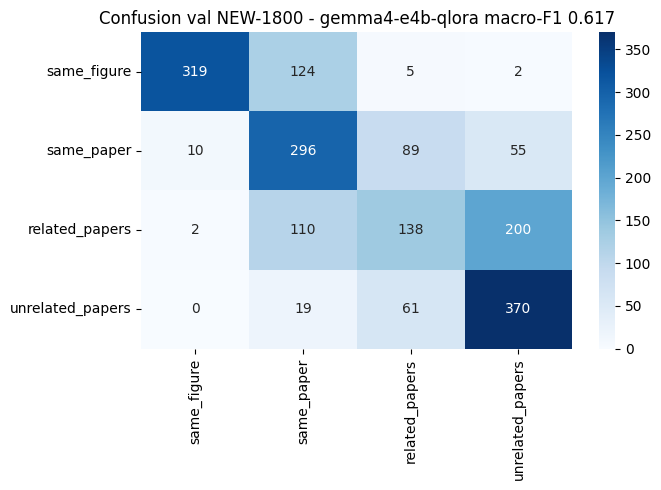

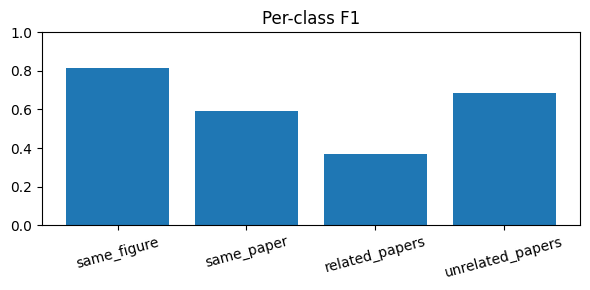

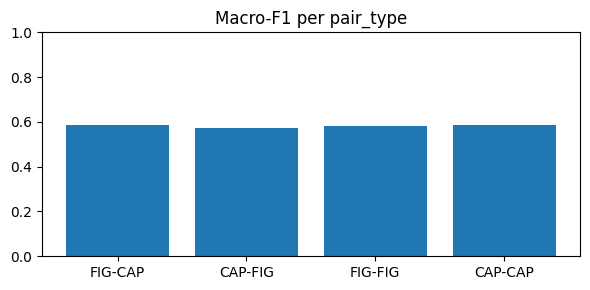

{
  "model": "google/gemma-4-E4B-it",
  "adapter": "ShivRamSaud/gemma4-e4b-qlora-astroclimb/adapter_best",
  "data": "NEW-23col-1800",
  "overall": {
    "acc": 0.6238888888888889,
    "macro_f1": 0.6170137014077717,
    "per_class": {
      "same_figure": 0.8169014084507042,
      "same_paper": 0.5925925925925926,
      "related_papers": 0.3714670255720054,
      "unrelated_papers": 0.6870937790157846
    }
  },
  "per_pair": {
    "FIG-CAP": 0.5862399204114663,
    "CAP-FIG": 0.5727878478567083,
    "FIG-FIG": 0.5805230228574368,
    "CAP-CAP": 0.5883200052502565
  },
  "n_scored": 1800,
  "n_total": 1800,
  "n_skipped": 0,
  "n_oom_fallbacks": 0,
  "n_parse_fallbacks": 0,
  "gen": {
    "greedy": true,
    "max_new_tokens": 32
  }
}


In [9]:
# --- 6b. Per-pair-type F1 + plots + metrics.json ---
scored_idx=[json.loads(l)['idx'] for l in open(os.path.join(OUT_DIR,'raw_outputs_final.jsonl'))]
_pairs=df.iloc[scored_idx]['pair_type'].values
pair_f1={}
for pt in ['FIG-CAP','CAP-FIG','FIG-FIG','CAP-CAP']:
    m=_pairs==pt
    if m.sum()==0: print(f'{pt} n=0 (no scored rows)'); continue
    f=f1_score(y_true[m], y_pred[m], average='macro')
    pair_f1[pt]=float(f); print(f'{pt}  n={m.sum()} macro-F1={f:.4f}')
plt.figure(figsize=(7,5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_COLS, yticklabels=LABEL_COLS)
plt.title(f'Confusion val NEW-1800 - gemma4-e4b-qlora macro-F1 {macro:.3f}'); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'confusion.png'), dpi=150); plt.show()
plt.figure(figsize=(6,3)); plt.bar(LABEL_COLS, per_class); plt.title('Per-class F1'); plt.ylim(0,1); plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'per_class_f1.png')); plt.show()
plt.figure(figsize=(6,3)); plt.bar(list(pair_f1.keys()), list(pair_f1.values())); plt.title('Macro-F1 per pair_type'); plt.ylim(0,1); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'per_pair_f1.png')); plt.show()
metrics={"model":MODEL_ID,"adapter":f"{HF_REPO_ID}/{ADAPTER_SUBFOLDER}","data":"NEW-23col-1800","overall":{"acc":float(acc),"macro_f1":float(macro),"per_class":dict(zip(LABEL_COLS,per_class.tolist()))},"per_pair":pair_f1,"n_scored":int(len(y_true)),"n_total":int(len(df)),"n_skipped":len(skipped),"n_oom_fallbacks":int(n_oom),"n_parse_fallbacks":int(n_parse_fb),"gen":{"greedy":True,"max_new_tokens":MAX_NEW_TOKENS}}
json.dump(metrics, open(os.path.join(OUT_DIR,'metrics.json'),'w'), indent=2)
print(json.dumps(metrics, indent=2))


In [10]:
# --- 7. Save: /kaggle/working + push eval/ to HF repo ---
from huggingface_hub import HfApi
print('OUT_DIR contents:', sorted(os.listdir(OUT_DIR)))
api=HfApi(); api.create_repo(repo_id=HF_REPO_ID, private=True, exist_ok=True)
try:
    api.upload_folder(repo_id=HF_REPO_ID, folder_path=OUT_DIR, path_in_repo="eval", commit_message=f"NEW-data val macro-F1 {macro:.4f} acc {acc:.4f} n {len(y_true)}")
    print(f"Pushed {OUT_DIR} -> {HF_REPO_ID}/eval")
except Exception as e: print(f'eval push failed {e} - files still in {OUT_DIR}')


OUT_DIR contents: ['confusion.png', 'metrics.json', 'per_class_f1.png', 'per_pair_f1.png', 'preds_val_1000.npy', 'preds_val_1200.npy', 'preds_val_1400.npy', 'preds_val_1600.npy', 'preds_val_1800.npy', 'preds_val_200.npy', 'preds_val_400.npy', 'preds_val_600.npy', 'preds_val_800.npy', 'preds_val_final.npy', 'raw_outputs.jsonl', 'raw_outputs_final.jsonl', 'skipped.json']


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed /kaggle/working/gemma_e4b_eval_new -> ShivRamSaud/gemma4-e4b-qlora-astroclimb/eval


In [11]:
# --- 8. Merge LoRA -> bf16 full model + push merged_best (importable later) ---
import gc
torch.cuda.empty_cache(); gc.collect()
try:
    print('Merging adapter into base (bf16 full model ~16GB)...')
    merged = model.merge_and_unload()
    merged.save_pretrained(MERGED_DIR, safe_serialization=True, max_shard_size='4GB')
    processor.save_pretrained(MERGED_DIR)
    print('Merged saved:', sorted(os.listdir(MERGED_DIR)))
    api.upload_folder(repo_id=HF_REPO_ID, folder_path=MERGED_DIR, path_in_repo='merged_best', commit_message=f'merged bf16 from {ADAPTER_SUBFOLDER} (NEW-val macro-F1 {macro:.4f})')
    print(f'Merged pushed -> {HF_REPO_ID}/merged_best (load later: AutoModelForMultimodalLM.from_pretrained, no peft needed)')
except Exception as e:
    print(f'MERGE SKIPPED: {e}')
    print('adapter_best + eval/ already safe - merge later on a bigger GPU from the pushed adapter')


Merging adapter into base (bf16 full model ~16GB)...


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:373: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Writing model shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merged saved: ['chat_template.jinja', 'config.json', 'generation_config.json', 'model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors', 'model.safetensors.index.json', 'processor_config.json', 'tokenizer.json', 'tokenizer_config.json']


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Merged pushed -> ShivRamSaud/gemma4-e4b-qlora-astroclimb/merged_best (load later: AutoModelForMultimodalLM.from_pretrained, no peft needed)


In [12]:
# --- 9. Summary ---
print(f"Model: {MODEL_ID} + {ADAPTER_SUBFOLDER} | data: NEW-23col scored {len(y_true)}/{len(df)} skipped {len(skipped)}")
print(f"NEW-val acc={acc:.4f} macro-F1={macro:.4f} (finetune-train val_loss best was 0.3489; old-format baseline 0.4408 = different rows, not comparable)")
print(f"HF: {HF_REPO_ID}/eval + {HF_REPO_ID}/merged_best")
print('Next: test.csv -> submission.csv (separate session, merged_best loads with no peft)')


Model: google/gemma-4-E4B-it + adapter_best | data: NEW-23col scored 1800/1800 skipped 0
NEW-val acc=0.6239 macro-F1=0.6170 (finetune-train val_loss best was 0.3489; old-format baseline 0.4408 = different rows, not comparable)
HF: ShivRamSaud/gemma4-e4b-qlora-astroclimb/eval + ShivRamSaud/gemma4-e4b-qlora-astroclimb/merged_best
Next: test.csv -> submission.csv (separate session, merged_best loads with no peft)
